# Problem set 5: Descriptive economics II - comments/solutions

# Programming for Economists Summer 2026: Class 9
**Matias BF Hall**

In [104]:
# Uncomment below to install the required package

# %pip install git+https://github.com/alemartinello/dstapi

**Table of contents**<a id='toc0_'></a>    
- 1. [National account identity](#toc1_)    
  - 1.1. [Download](#toc1_1_)    
  - 1.2. [Merge](#toc1_2_)    
  - 1.3. [Split-apply-combine-plot](#toc1_3_)    
- 2. [Disaggregated inflation in Denmark](#toc2_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [105]:
import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

from dstapi import DstApi

## 1. <a id='toc1_'></a>[National account identity](#toc0_)

We want to check the **national account identity**

$$
Y = C + G + I + X - M
$$

where $Y$ is GDP, $C$ is private consumption, $G$ is government consumption, $I$ is gross capital formation, and $X$ and $M$ are exports and imports.

We use two tables from Statistics Denmark:

1. `NAH1` for the **components** ($C$, $G$, $I$, $X$, $M$)
1. `NAN1` for **GDP** itself

**Note:** `NAH1` does *not* contain GDP. It contains `P.1 Output`, which is *gross output* - the total value of everything produced, including the intermediate goods that are used up again in production. Gross output is roughly 1.8 times GDP, so it cannot be used as $Y$.

### 1.1. <a id='toc1_1_'></a>[Download](#toc0_)

Consider the following dictionary definitions:

**Note:** *Private consumption* $C$ consists of **two** categories in the national accounts: consumption by households, and consumption by non-profit institutions serving households (NPISH). Both are therefore mapped to `C`, and you will have to add them together in step 3.

In [106]:
# Here Jeppe has created dictionaries to map the variable names from the API to more standard names
# and to map the variable and unit names to shorter versions
# You can use these dictionaries in the rename method to rename the columns and to map the variable

columns_dict = {}
columns_dict['TRANSAKT'] = 'variable'
columns_dict['PRISENHED'] = 'unit'
columns_dict['TID'] = 'year'
columns_dict['INDHOLD'] = 'value'

var_dict = {} # var is for variable
var_dict['P.31 Household consumption expenditure'] = 'C'
var_dict['P.31 Non-profit institutions serving households (NPISH) consumption expenditure'] = 'C'
var_dict['P.3 Government consumption expenditure'] = 'G'
var_dict['P.5 Gross capital formation'] = 'I'
var_dict['P.6 Export of goods and services'] = 'X'
var_dict['P.7 Import of goods and services'] = 'M'

unit_dict = {}
unit_dict['2020-prices, chained values'] = 'real'
unit_dict['Current prices'] = 'nominal'

**Step 1:** Download all of table `nah1`.

In [107]:
# Use the DST API to make an API for the nah1 dataset
nah1_api = DstApi('nah1') 
# Use the api to get a dictionary of parameter names in english
params = nah1_api._define_base_params(language='en')
# When looking at the parameters we see e.g. that the table name is 'nah1'
display(params)
# Use the api to get the data with the parameters just defined
nah1 = nah1_api.get_data(params=params)

{'table': 'nah1',
 'format': 'BULK',
 'lang': 'en',
 'variables': [{'code': 'TRANSAKT', 'values': ['*']},
  {'code': 'PRISENHED', 'values': ['*']},
  {'code': 'Tid', 'values': ['*']}]}

**Step 2:** Rename the columns using `columns_dict` and replace data using `var_dict` and `unit_dict`.

In [108]:
# renaming the columns using the columns_dict
nah1 = nah1.rename(columns=columns_dict)

# renaming the variables using the var_dict and unit_dict
# Looping through the key and value in the dictionaries, we replace every row
# named the same as the key with the value
for key,value in var_dict.items():
   nah1.variable = nah1.variable.replace(key,value)

for key,value in unit_dict.items():
   nah1.unit = nah1.unit.replace(key,value)

**Step 3:** Only keep rows where the variable is in `[C, G, I, X, M]`. Convert the `value` column to a float. Finally **add the two private consumption categories together**, so there is only one `C` per unit and year.

In [109]:
# Keep only the variables in var_dict
# We use the or operator | to keep the true values from previous iterations
I = False
for key,value in var_dict.items():
    I = I | (nah1.variable == value)
nah1 = nah1.loc[I]

# Convert the value column to float
nah1.value = nah1.value.astype('float')

# hint, add the two consumption categories together:
# we group by variable, unit and year and sum the values. This will give us one row for each variable, unit and year combination
nah1 = nah1.groupby(['variable','unit','year'],as_index=False)['value'].sum()
# before this operation we had 2 C's for each year, now we have one C for each year

**Step 4:** Download GDP from table `NAN1` (`TRANSAKT = B1GQK`) and add it to the dataset as the variable `Y`.

**Careful with two things:**

1. `NAH1` is in **mio. DKK**, but `NAN1` is in **bill. DKK**.
1. The price-unit labels in `NAN1` are not the same strings as in `NAH1` - they have the unit appended, e.g. `Current prices, (bill. DKK.)` - so `unit_dict` does not work on them directly.

In [110]:
# params is just the a dictionary of parameters we want to use
params = {'table':'NAN1','format':'BULK','lang':'en','variables':[
    {'code':'TRANSAKT','values':['B1GQK']},
    {'code':'PRISENHED','values':['V_M','LAN_M']},
    {'code':'Tid','values':['*']}]}
# get data using parameters above
gdp = DstApi('NAN1').get_data(params=params)

# I looked at gdp.head() to look up the current names
# gdp.head()
# create var and unit dictionary for gdp
var_dict = {}
var_dict['B.1*g Gross domestic product'] = 'Y'

unit_dict = {}
unit_dict['2020-prices, chained values, (bill. DKK.)'] = 'real'
unit_dict['Current prices, (bill. DKK.)'] = 'nominal'

# use existing columns_dict to rename columns in gdp and use var_dict and unit_dict to rename variables and units in gdp
gdp = gdp.rename(columns=columns_dict)
for key,value in var_dict.items():
   gdp.variable = gdp.variable.replace(key,value)
for key,value in unit_dict.items():
   gdp.unit = gdp.unit.replace(key,value)

# convert value column to float
gdp.value = gdp.value.astype('float')

# convert the gdp from billion to million
gdp.value = gdp.value * 1000

#hint, stack it on top of the other data:
nah1 = pd.concat([nah1,gdp],ignore_index=True) # we ignore index to avoid duplicate index values

**Step 5:** Check the national account identity, $Y = C + G + I + X - M$.

Does it hold in current prices? Does it hold in 2020-prices (chained values)? Explain what you find.

*Hint:* A small discrepancy of a few mio. DKK is just rounding in the published figures.

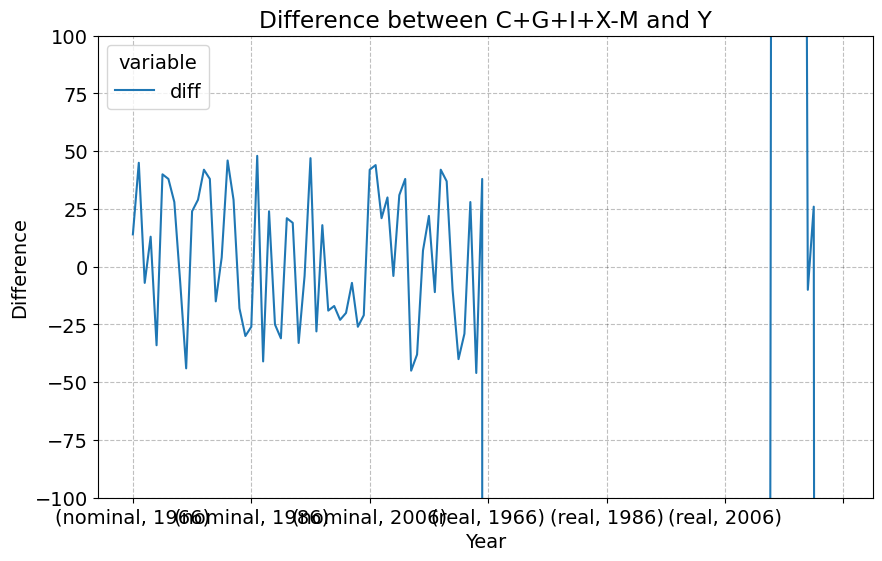

In [111]:
# hint, put the variables in columns:
# check simply flips the table keeping unit and year as row identifiers and variables as columns. We take the values as the values
check = nah1.pivot_table(index=['unit','year'],columns='variable',values='value')

# create column with the sum
check['C+G+I+X-M'] = check.C + check.G + check.I + check.X - check.M
# create column with the difference
check['diff'] = check['C+G+I+X-M'] - check.Y

# plot to easily see the difference
plot = check.plot(y=['diff'], figsize=(10,6), title='Difference between C+G+I+X-M and Y', ylabel='Difference', xlabel='Year')
plot.set_ylim(-100, 100);

***Comment***
The nominal account identity holds (with rounding errors). The real account identity does not hold, because each part has it's own inflation index, why the individually deflated values does not sum to the whole. Real values still hold around 2020 (with rounding errors) because they are all in the same prices.

**Step 6:** Discuss what the following summary statistics show.

In [112]:
nah1.groupby(['variable','unit']).describe()
# I'll let you interpret the results, but one quick looks shows that there has been growth in all variables

year                                                       \
                 count    mean        std     min      25%     50%      75%   
variable unit                                                                 
C        nominal  60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
         real     60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
G        nominal  60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
         real     60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
I        nominal  60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
         real     60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
M        nominal  60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
         real     60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
X        nominal  60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
         real     60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
Y        nominal  60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   
         real     60.0  1995.5  17.464249  1966.0  1980.75  1995.5  2010.25   

                         value                                         \
                     max count          mean            std       min   
variable unit                                                           
C        nominal  2025.0  60.0  5.731773e+05  378310.865231   47808.0   
         real     2025.0  60.0  7.756850e+05  218592.620563  391557.0   
G        nominal  2025.0  60.0  2.935556e+05  204513.642197   14768.0   
         real     2025.0  60.0  4.234492e+05  121264.550235  189310.0   
I        nominal  2025.0  60.0  2.614647e+05  195425.409475   21134.0   
         real     2025.0  60.0  3.270933e+05  142239.516822  137948.0   
M        nominal  2025.0  60.0  5.383283e+05  494589.317358   24406.0   
         real     2025.0  60.0  5.735079e+05  400629.745564  116721.0   
X        nominal  2025.0  60.0  6.062615e+05  567741.000710   23110.0   
         real     2025.0  60.0  6.835133e+05  458489.389877  129917.0   
Y        nominal  2025.0  60.0  1.196127e+06  845654.962469   82400.0   
         real     2025.0  60.0  1.656733e+06  530592.223223  760000.0   

                                                                
                         25%        50%         75%        max  
variable unit                                                   
C        nominal   232335.25   534626.5   875783.75  1344007.0  
         real      586275.25   769204.5   957403.25  1150866.0  
G        nominal   115402.75   255812.0   492661.25   717008.0  
         real      346604.75   407803.0   546717.50   610443.0  
I        nominal    84304.00   215717.0   380681.00   741339.0  
         real      202118.75   296262.5   419911.00   645849.0  
M        nominal   147635.00   336733.5   892965.50  1820329.0  
         real      226957.25   410623.5   899813.00  1457108.0  
X        nominal   151834.50   391949.5   982480.50  2158183.0  
         real      281755.25   541928.5  1063269.50  1748987.0  
Y        nominal   428125.00  1061350.0  1821800.00  3118500.0  
         real     1166625.00  1640850.0  2083000.00  2704300.0

**Step 7:** Sort the dataset by year

In [113]:
nah1 = nah1.sort_values(by='year')
nah1.head()

,variable,unit,year,value
0,C,nominal,1966,47808.0
300,I,real,1966,137948.0
180,G,real,1966,189310.0
360,M,nominal,1966,24406.0
420,M,real,1966,116721.0


### 1.2. <a id='toc1_2_'></a>[Merge](#toc0_)

Load population data from Statistics Denmark:

In [114]:
BEFOLK1_api = DstApi('BEFOLK1')
params = BEFOLK1_api._define_base_params(language='en')
display(params)

{'table': 'befolk1',
 'format': 'BULK',
 'lang': 'en',
 'variables': [{'code': 'KØN', 'values': ['*']},
  {'code': 'ALDER', 'values': ['*']},
  {'code': 'CIVILSTAND', 'values': ['*']},
  {'code': 'Tid', 'values': ['*']}]}

In [115]:
for code in ['KØN','CIVILSTAND']:
    print(code)
    display(BEFOLK1_api.variable_levels(code,language='en'))
    print('')

KØN


,id,text
0,TOT,I alt
1,1,Mænd
2,2,Kvinder



CIVILSTAND


,id,text
0,TOT,I alt
1,U,Ugift
2,G,Gift/separeret
3,E,Enke/enkemand
4,F,Fraskilt


In [116]:
params['variables'][0]['values'] = ['TOT'] 
params['variables'][2]['values'] = ['TOT'] 
BEFOLK1 = BEFOLK1_api.get_data(params=params)
display(BEFOLK1.head())

,KØN,ALDER,CIVILSTAND,TID,INDHOLD
0,Total,"Age, total",Total,1993,5180614
1,Total,0 years,Total,1993,67651
2,Total,1 year,Total,1993,64656
3,Total,10 years,Total,1993,54088
4,Total,11 years,Total,1993,54404


In [117]:
BEFOLK1 = BEFOLK1.rename(columns={'TID':'year','INDHOLD':'population'})
BEFOLK1 = BEFOLK1.drop(columns=['KØN','CIVILSTAND'])
pop = BEFOLK1[BEFOLK1.ALDER == 'Age, total'].drop(columns=['ALDER'])
pop.head()

,year,population
0,1993,5180614
101,2001,5349212
202,1999,5313577
303,2018,5781190
404,1972,4975653


**Question a:** Merge the population and the national account data, so there is a new column called `population`. Use the **merge function**.

In [118]:
# Merging the two datasets on year, using a left join to keep all rows from nah1
# and only those from pop that match on year
merged = pd.merge(nah1,pop,how='left',on=['year'])
merged.tail(10)

,variable,unit,year,value,population
710,Y,real,2025,2704300.0,5992734.0
711,Y,nominal,2025,3118500.0,5992734.0
712,M,nominal,2025,1820329.0,5992734.0
713,C,real,2025,1139299.0,5992734.0
714,M,real,2025,1439151.0,5992734.0
715,X,nominal,2025,2158183.0,5992734.0
716,C,nominal,2025,1344007.0,5992734.0
717,X,real,2025,1748987.0,5992734.0
718,G,nominal,2025,717008.0,5992734.0
719,I,real,2025,616608.0,5992734.0


**Question b:** Merge the population on again, so there is a new column called `population_alt`. Use the **join method**.

In [119]:
# Make the year the index and rename the population column to population_alt
pop_with_index = pop.set_index('year')
pop_with_index = pop_with_index.rename(columns={'population':'population_alt'})

# Make the year the index for the merged DataFrame
merged_with_index = merged.set_index('year')

# Since the two DataFrames have the same index, we can use the join method to merge them
merged_alt = merged_with_index.join(pop_with_index)
merged_alt.tail(10)

,variable,unit,value,population,population_alt
year,,,,,
2025,Y,real,2704300.0,5992734.0,5992734.0
2025,Y,nominal,3118500.0,5992734.0,5992734.0
2025,M,nominal,1820329.0,5992734.0,5992734.0
2025,C,real,1139299.0,5992734.0,5992734.0
2025,M,real,1439151.0,5992734.0,5992734.0
2025,X,nominal,2158183.0,5992734.0,5992734.0
2025,C,nominal,1344007.0,5992734.0,5992734.0
2025,X,real,1748987.0,5992734.0,5992734.0
2025,G,nominal,717008.0,5992734.0,5992734.0


**Question c:** Plot GDP per capita and GDP per working-age (18-65) using the code below as a starting point.

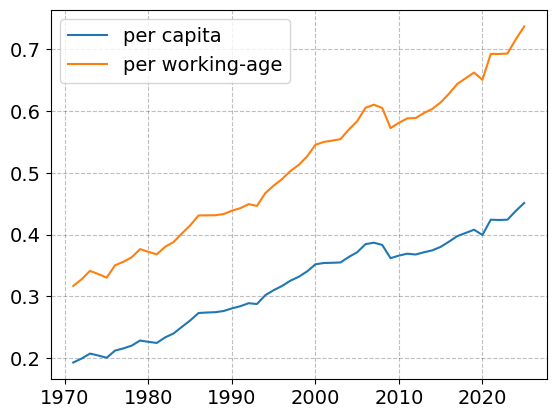

In [120]:
# As BEFOLK1.ALDER is a string variable,
# we use list comprehension to create a list of strings with the age and years
# Try looking at the dataframe Befolk1 to understand the format
ages = [f"{age} years" for age in range(18, 66)]

# Compute the working age population each year
# Read the code as: from BEFOLK1, keep only keep the rows in the list 'ages',
# then group by year and sum the population for each year
working_pop = BEFOLK1[BEFOLK1.ALDER.isin(ages)].groupby('year').sum()

# Clean up the dataframe a bit, see if you can understand what each line does
working_pop = working_pop.drop(columns=['ALDER'])
working_pop = working_pop.rename(columns={'population':'working_population'})

# Merge everything so far together
merged = pd.merge(nah1, working_pop, how='left', on=['year'])
merged = pd.merge(merged, pop, how='left', on=['year'])

# Plot the time series of GDP per capita and GDP per working age capita
# First we need to compute these variables
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# Compute the per capita value for all values in the dataframe
merged['value_pop'] = merged.value/merged.population
merged['value_working_pop'] = merged.value/merged.working_population

# Create filter for real GDP only
I = merged.unit == 'real' 
I &= merged.variable == 'Y' 

# Create new dataframe only with real GDP and with year as index for plotting
df = merged[I].set_index('year')

# Plot both series
ax.plot(df.value_pop, label='per capita')
ax.plot(df.value_working_pop, label='per working-age')

ax.legend();


### 1.3. <a id='toc1_3_'></a>[Split-apply-combine-plot](#toc0_)

Ensure the following code for a **split-apply-combine-plot** can run.

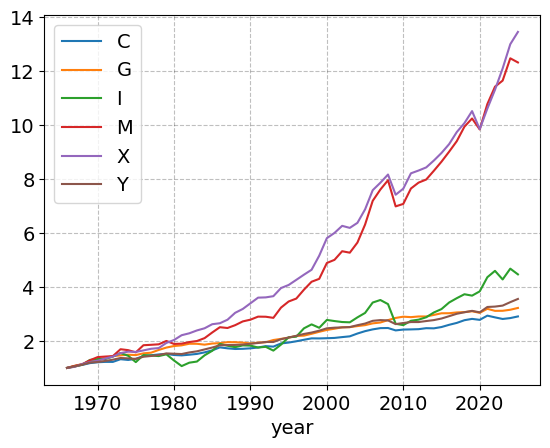

In [121]:
# a. split
nah1_grouped = nah1.groupby(['variable','unit'])
nah1_grouped_first = nah1_grouped.value.first()
nah1_grouped_first.name = 'first'
# We get the first value for each variable and unit combination

# b. apply
nah1_new = nah1.set_index(['variable','unit','year'])
nah1_new = nah1_new.join(nah1_grouped_first,how='left',on=['variable','unit'])
nah1_new = nah1_new.reset_index()
# Join the first value to each row based on variable and unit, then reset the index
# I use a different name so the original stays the same

# c. combine
nah1_new['indexed'] = nah1_new['value']/nah1_new['first']
# Create the indexed variable with the first value as base year

# d. plot
def plot(df,variable='indexed'):
    df_indexed = df.set_index('year')
    I = df_indexed.unit == 'real'
    df_indexed[I].groupby(['variable'])[variable].plot(legend=True);

plot(nah1_new)

**Question:** Implement the same split-apply-combine as above using `transform`.

In [122]:
def first(x): # select the first element in a series
    return x.iloc[0]

nah1_alt = nah1.copy()
grouped = nah1_alt.groupby(['variable','unit'])
nah1_alt['index_transform'] = grouped['value'].transform(lambda x: x/first(x))
# Using transform we can create the indexed variable directly without needing to join first values
# Using transform and the lambda function we apply the function to each group and 
# return a series with the same index and length as the original
nah1_alt.head()

,variable,unit,year,value,index_transform
0,C,nominal,1966,47808.0,1.0
300,I,real,1966,137948.0,1.0
180,G,real,1966,189310.0,1.0
360,M,nominal,1966,24406.0,1.0
420,M,real,1966,116721.0,1.0


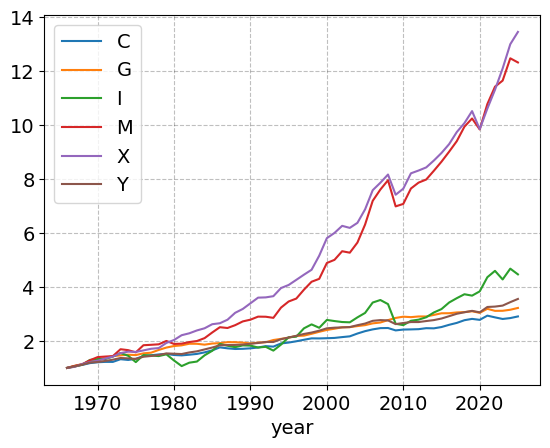

In [123]:
plot(nah1_alt,variable='index_transform')

## 2. <a id='toc2_'></a>[Disaggregated inflation in Denmark](#toc0_)

**Question 1:** Using table `PRIS111` from Statistics Denmark create a list of all 4-digit product categories (e.g. `01.1.1.1 Rice`)


In [124]:
# hint: start from the code below to get the levels of the variable VAREGR in PRIS111
levels = DstApi('PRIS111').variable_levels('VAREGR',language='en' )
for row in levels.itertuples(): print(row.id,row.text)

# function to check that the list is a 4 digit product category
# we check that the last two digits of the id are not 00 and that the first part of the text does not contain a / or a - which are used for subcategories
def verify(id,text):
    cond_1 = not (id[-2] == '0' and id[-1] == '0')
    cond_2 = not ('/' in text.split(' ')[0] or '-' in text.split(' ')[0])
    return cond_1 and cond_2

# using the function we create lists of all the valid category codes and their labels.
# we use list comprehension to iterate over the rows of the levels dataframe and apply the verify function to each row. If the row is valid, we add the id and text to the respective lists.
VAREGR_text = [row['text'] for _,row in levels.iterrows() if verify(row['id'], row['text'])]
VAREGR = [row['id'] for _,row in levels.iterrows() if verify(row['id'], row['text'])]

print('\n')
print(f'{len(VAREGR)} categories found.')
print(VAREGR_text[30])

000000 00 Consumer price index, total
010000 01 Food and non-alcoholic beverages
011000 01.1 Food
011100 01.1.1 Bread and cereals
011110 01.1.1.1 Rice
011120 01.1.1.2 Flours and other cereals
011130 01.1.1.3 Bread
011140 01.1.1.4 Other bakery products
011150 01.1.1.5 Pizza and quiche
011160 01.1.1.6 Pasta products and couscous
011170 01.1.1.7 Breakfast cereals
011180 01.1.1.8 Other cereal products
011200 01.1.2 Meat
011210 01.1.2.1 Beef and veal
011220 01.1.2.2 Pork
011230 01.1.2.3 Lamb and goat
011240 01.1.2.4 Poultry
011260 01.1.2.6 Edible offal
011270 01.1.2.7 Dried, salted or smoked meat
011280 01.1.2.8 Other meat preparations
011300 01.1.3 Fish and seafood
011310 01.1.3.1 Fresh or chilled fish
011320 01.1.3.2 Frozen fish
011340 01.1.3.4 Frozen seafood
011350 01.1.3.5 Dried, smoked or salted fish and seafood
011360 01.1.3.6 Other preserved or processed fish and seafood-based preparations
011400 01.1.4 Milk, cheese and eggs
011410 01.1.4.1 Milk, whole, fresh
011420 01.1.4.2 Milk, lo

In [125]:
# download the data

PRIS111 = DstApi('PRIS111')

# use the built in method to get all parameters
params = PRIS111._define_base_params(language='en')
VAREGR = {'code': 'VAREGR','values': VAREGR}
ENHED = {'code': 'ENHED','values': ['100']}
TID = {'code': 'Tid','values': ['*']} # * means we get all years, but we can also specify a list of years or a range of years. For example, ['2020','2021'] or ['2020','2021','2022'] or ['2020','2021','2022','2023'] or ['2020','2021','2022','2023','2024'] or ['2020','2021','2022','2023','2024','2025'] or ['2020','2021','2022','2023','2024','2025','2026'] or ['2019-01-01/2019-12-31'] or ['2019-01-01/2019-12-31', '2020-01-01/2020-12-31'] or ['2019-01-01/2019-12-31', '2020-01-01/2020-12-31', '2021-01-01/2021-12-31'] or ['2019-01-01/2019-12-31', '2020-01-01/2020-12-31', '2021-01-01/2021-12-31', '2022-01-01/2022-12-31'] or ['2019-01-01/2019-12-31', '2020-01-01/2020-12-31', '2021-01-01/2021-12-31', '2022-01-01/2022-12-31', '2023-01
# using the above defined dictionaries and the VARGR list only containing valid product categories, we can get the data from PRIS111.
params['variables'] = [VAREGR,ENHED,TID]
df_CPI_details = PRIS111.get_data(params)

In [126]:
# clean the data, such as datetime, dropping columns, renaming columns, replacing missing values, converting to float, and sorting the data.

df_CPI_details['TID'] = pd.to_datetime(df_CPI_details['TID'], format='%YM%m')
df_CPI_details = df_CPI_details.drop(columns='ENHED')
df_CPI_details = df_CPI_details.rename(columns={'TID':'date','VAREGR':'item','INDHOLD':'CPI'})
df_CPI_details.CPI = df_CPI_details.CPI.replace('..','nan')
df_CPI_details.CPI = df_CPI_details.CPI.astype(float)
df_CPI_details = df_CPI_details.sort_values(['item','date'])
df_CPI_details.tail()

,item,date,CPI
46217,12.7.0.3 Funeral services,2025-08-01,132.7
10382,12.7.0.3 Funeral services,2025-09-01,132.7
43665,12.7.0.3 Funeral services,2025-10-01,132.7
37404,12.7.0.3 Funeral services,2025-11-01,132.7
14677,12.7.0.3 Funeral services,2025-12-01,132.7


**Question 2:** Compute the 12-month inflation rate for the 4-digit product categories
using `.groupby` and compute the 25th, 50th and 75th percentile 
for each month in the data using `.agg`. Plot and describe
what you see.



In [127]:
# write your code here

# compute the 12-month inflation rate for each item in the CPI dataset. We use the groupby method to group the data by item, 
# and then we use the transform method to apply a lambda function that calculates the percentage change over 12 months.
df_CPI_details['inflation_12'] = df_CPI_details.groupby('item').CPI.transform(lambda x: x.pct_change(12, fill_method=None)*100)

# compute the aggregated statistics using the .agg method and quantile method. x is a series of inflation rates for each item in the CPI dataset.
df_CPI_details_agg = df_CPI_details.groupby('date').inflation_12.agg(
    p25 = lambda x: x.quantile(0.25),
    median = lambda x: x.quantile(0.5),
    p75 = lambda x: x.quantile(0.75),
    mean = 'mean'
    )
df_CPI_details_agg.tail()

,p25,median,p75,mean
date,,,,
2025-08-01,-0.492211,1.851852,3.865200,1.961282
2025-09-01,-1.154418,1.433121,4.061775,1.713398
2025-10-01,-0.385745,1.836158,4.677377,1.942890
2025-11-01,-0.770528,1.802403,4.428800,1.695703
2025-12-01,-1.228592,1.663340,4.082235,1.272859


In [128]:
# needed variables (from PS4)

PRIS113 = DstApi('PRIS113')
params = PRIS113._define_base_params()
df_CPI = PRIS113.get_data(params)

# b. clean data
df_CPI = df_CPI.drop(columns=['TYPE'])
df_CPI['TID'] = pd.to_datetime(df_CPI['TID'],format='%YM%m')
df_CPI = df_CPI.rename(columns={'TID':'date','INDHOLD':'CPI'})
df_CPI = df_CPI.set_index('date').sort_index()

# c. index to 2020=100
df_CPI.CPI = df_CPI.CPI/df_CPI[df_CPI.index.year==2020].CPI.mean()*100

# d. compute the 12-month inflation rate
df_CPI['inflation_12'] = df_CPI['CPI'].pct_change(periods=12)*100

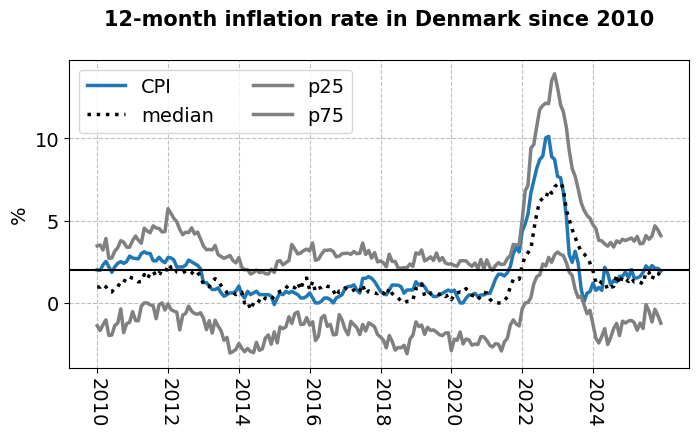

In [129]:
# plot

I = df_CPI.index >= pd.to_datetime(2010,format='%Y')
J = df_CPI_details_agg.index >= pd.to_datetime(2010,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI[I].index,df_CPI[I]['inflation_12'],lw=2.5,label='CPI')
ax.plot(df_CPI_details_agg[J].index,df_CPI_details_agg[J]['median'],label='median',color='black',lw=2.5,ls=':')
for name in ['p25','p75']:
    ax.plot(df_CPI_details_agg[J].index,df_CPI_details_agg[J][name],label=name,color='grey',lw=2.5,ls='-')

ax.axhline(2.0,color='black')

ax.set_xticks(df_CPI[I].index[::24])
ax.set_xticklabels(df_CPI[I].index[::24].year,rotation=270);

ax.set_ylabel('%')
ax.legend(ncol=2)
ax.set_title('12-month inflation rate in Denmark since 2010',
             pad=25.0,fontdict={'fontsize': 15, 'fontweight': 'bold'});

**Question 3:** Plot the histogram of the percent change in prices for 4-digit product
categories from August 2020 to August 2025. Describe what you see.


In [130]:
# write your code here

# get the percentage change in the 4-digit product categories from 2020 to 2025, by aggregating the data by item and calculating the first and last values of the CPI for each item, 
# then calculating the percentage change between these two values.
I = (df_CPI_details.date == '2020-08-01') | (df_CPI_details.date == '2025-08-01')
df_since_2020 = df_CPI_details[I].groupby('item').CPI.agg(['first','last'])
df_since_2020['change'] = (df_since_2020['last']/df_since_2020['first']-1)*100
df_since_2020 = df_since_2020.sort_values('change',ascending=False)
df_since_2020 = df_since_2020.dropna(subset=['change'])
df_since_2020.head().style.format('{:.1f}')


,first,last,change
item,,,
08.1.0.1 Letter handling services,211.7,382.3,80.6
01.2.1.1 Coffee,97.4,165.3,69.7
02.2.0.3 Other tobacco products,109.2,180.4,65.2
07.3.3.1 Domestic flights,72.5,118.0,62.8
01.1.5.1 Butter,123.5,194.0,57.1


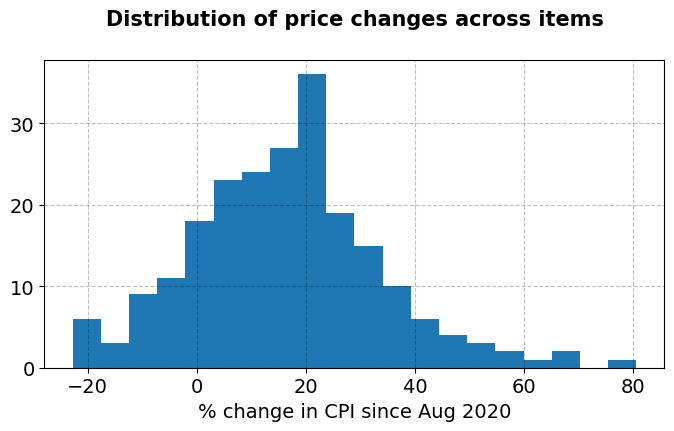

In [131]:
# plot
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)
ax.hist(df_since_2020.change.to_numpy(),bins=20)
ax.set_xlabel('% change in CPI since Aug 2020')
ax.set_title('Distribution of price changes across items',
                pad=25.0,fontdict={'fontsize': 15, 'fontweight': 'bold'});

**Question 4:** Illustrate the top 10 and bottom 10 product categories.

In [132]:
# create dateframe containing the top and bottom changes
top10 = df_since_2020.nlargest(10, 'change')
bottom10 = df_since_2020.nsmallest(10, 'change')
top_bottom = pd.concat([top10, bottom10])
top_bottom_sorted = top_bottom.sort_values('change')

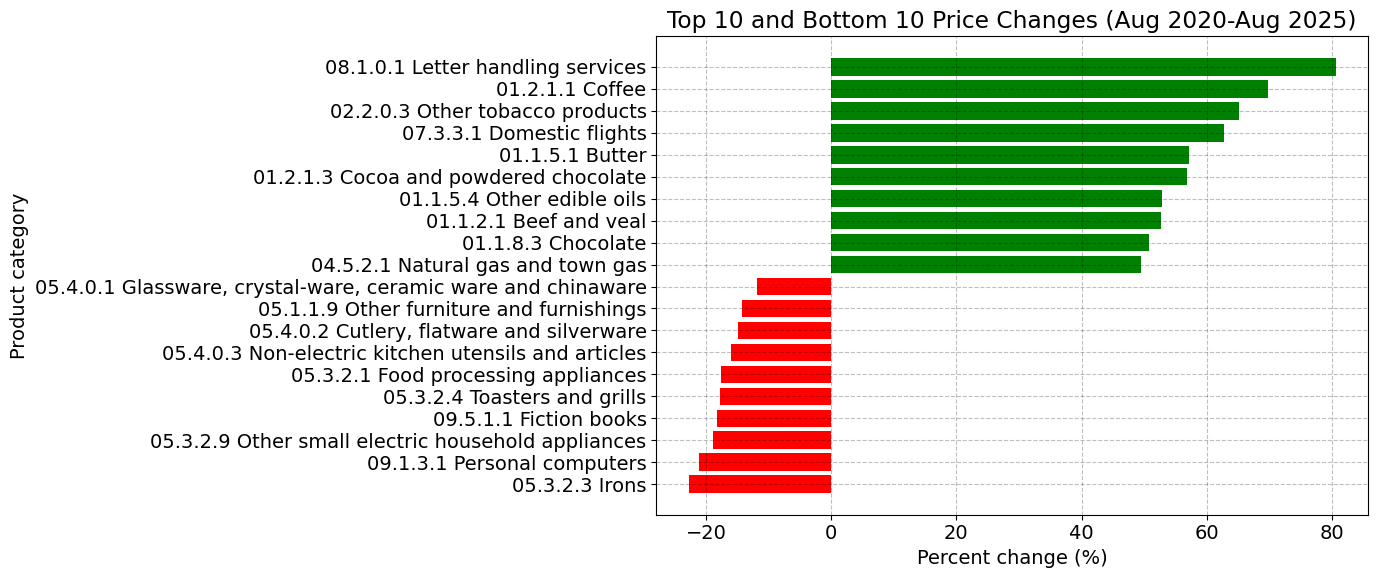

In [133]:
# plot
plt.figure(figsize=(14,6))
colors = ['green' if x > 0 else 'red' for x in top_bottom_sorted['change']]
plt.barh(top_bottom_sorted.index, top_bottom_sorted['change'], color=colors)
plt.title('Top 10 and Bottom 10 Price Changes (Aug 2020-Aug 2025)')
plt.xlabel('Percent change (%)')
plt.ylabel('Product category')
plt.tight_layout()
plt.show()
